In [1]:
1+1

2

In [2]:
words = open("./data/names.txt").read().splitlines()
words[:3]

['emma', 'olivia', 'ava']

In [3]:
len(words)

32033

Building the vocabulary

In [4]:
chars = sorted((list(set(''.join(words)))))
stoi = {s:i+1 for i,s in enumerate(chars) }
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [98]:
import torch

BLOCK_SIZE = 3 # how many chars do you want to use to predict the next char?
X, y = [], []

for w in words:
    context = [0] * BLOCK_SIZE

    for ch in w+'.':
        X.append(context)
        ix = stoi[ch]
        y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
y = torch.tensor(y)

Building the embedding look up table C 

In [33]:
C = torch.randn((27,2))
C

tensor([[ 0.7195, -3.2008],
        [ 1.5087, -0.9011],
        [-1.4859,  0.6823],
        [-0.3819,  0.5657],
        [-1.1059,  0.5310],
        [ 1.2415,  1.6227],
        [-2.3096, -0.0304],
        [-1.0531, -0.4351],
        [-1.0897,  1.0515],
        [-0.2830,  0.9650],
        [-1.0010,  0.0328],
        [ 1.2750, -1.7068],
        [ 1.4416,  1.8915],
        [ 1.2671, -0.6552],
        [-1.1981,  1.5150],
        [ 1.7167, -0.3057],
        [-0.7802, -0.4025],
        [-0.7221,  0.3967],
        [ 1.0599, -0.5805],
        [-0.4281, -0.9998],
        [ 1.0312,  0.7162],
        [-0.2002, -1.1142],
        [-0.2522, -0.1763],
        [ 0.4454, -0.0324],
        [ 1.0333, -0.6758],
        [-0.9875,  1.1596],
        [-0.1677, -0.2038]])

Just a detour to understand what onehotENcoding does

In [34]:
# So if i want the 5th row of C, I can do

C[5]

tensor([1.2415, 1.6227])

In [40]:
# Another way of doing this is

import torch.nn.functional as F

F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([1.2415, 1.6227])

So one hot does nothing but just makes it easier to look up stuff using a vector, inside another vector

But we will be using C[5] and not onehot

In [99]:
X.shape

torch.Size([228146, 3])

In [47]:
C[X].shape

torch.Size([32, 3, 2])

In [50]:
X[13, 2]

tensor(1)

In [51]:
C[X][13,2]

tensor([ 1.5087, -0.9011])

In [52]:
C[1]

tensor([ 1.5087, -0.9011])

In short python indexing is cool and we can use such stuff to index

In [54]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

emb consists of 32 rows, where each row is of 3 chars and each char is of 2 embeds,

now to input this into our weights we need to take 2 embeds for each char, now for each training loop, we are taking 3 chars in X, so total embeds per X is 3*2 therefore we need 3*2 = 6 inputs .... We are taking 100 such neurons in the 1st layer, with 6 inputs each

In [62]:
W1 = torch.randn((3*2, 100)) 
b1 = torch.randn(100)

In [63]:
# ideally we want to do 

emb @ W1 + b1

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

But since shapes dont match, we can do this

rightnow, we have 3*2 shape for each X, where 3 is the number of chars and 2 is the embeds for them...
Now what if we multiply them, so all the embeds are next to each other, like embed1ForChar1, embed2ForChar1, embed1ForChar2, embed2ForChar2, in a single row, now....those 3*2 shape will become 1*6

therefore we will concatnate these rows and make them a row

In [ ]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1).shape

torch.Size([32, 6])

In [67]:
# another way of doing this is by viewing the tensor

emb.view(32, 6) == torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], dim=1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

What is a view??

Well, every tensor in pytorch is stored actually as a 1d tensor, which is accessed by tensor.storage(), and view gives us a copy of that storage which we can manipulate however we want

In [68]:
emb.storage()

/tmp/ipykernel_2523/433807246.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  emb.storage()


 0.7195050716400146
 -3.200831413269043
 0.7195050716400146
 -3.200831413269043
 0.7195050716400146
 -3.200831413269043
 0.7195050716400146
 -3.200831413269043
 0.7195050716400146
 -3.200831413269043
 1.241454005241394
 1.622706413269043
 0.7195050716400146
 -3.200831413269043
 1.241454005241394
 1.622706413269043
 1.267134189605713
 -0.655203640460968
 1.241454005241394
 1.622706413269043
 1.267134189605713
 -0.655203640460968
 1.267134189605713
 -0.655203640460968
 1.267134189605713
 -0.655203640460968
 1.267134189605713
 -0.655203640460968
 1.5086699724197388
 -0.9010775089263916
 0.7195050716400146
 -3.200831413269043
 0.7195050716400146
 -3.200831413269043
 0.7195050716400146
 -3.200831413269043
 0.7195050716400146
 -3.200831413269043
 0.7195050716400146
 -3.200831413269043
 1.7166504859924316
 -0.3057396113872528
 0.7195050716400146
 -3.200831413269043
 1.7166504859924316
 -0.3057396113872528
 1.4416459798812866
 1.891503095626831
 1.7166504859924316
 -0.3057396113872528
 1.44164

In [72]:
# so we can do this

h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1)
h.shape

torch.Size([32, 100])

In [74]:
h[0]

tensor([ 1.0000, -0.9998, -0.6413,  1.0000, -0.9997, -0.6379,  1.0000,  0.2376,
        -0.9908,  0.9985,  0.9740, -1.0000, -0.9693, -0.9993, -0.9715,  0.5274,
        -0.9906, -0.9998,  0.9989, -1.0000,  1.0000,  0.9974, -1.0000, -0.0210,
        -0.9868, -0.9305, -1.0000,  1.0000,  0.8358,  0.9993,  0.9982,  1.0000,
         1.0000,  1.0000,  0.3590, -0.9989,  0.9658, -0.9936,  1.0000, -0.4528,
        -0.9815,  0.0663,  0.9888,  0.4749,  1.0000, -0.2740, -0.9855, -1.0000,
         1.0000, -1.0000, -0.9999,  0.6567, -0.9998,  1.0000, -0.9999, -0.9587,
        -0.4357, -0.6231,  1.0000, -1.0000, -0.9996,  1.0000,  0.9999,  1.0000,
        -0.9944,  0.6109, -0.3515,  1.0000, -1.0000,  0.9656,  1.0000, -0.9991,
         0.8061, -1.0000, -0.9999, -0.9999, -0.7001,  0.9029, -0.8919,  1.0000,
         0.9988,  1.0000, -0.0627, -0.8804, -0.9947,  1.0000,  0.0943,  0.9984,
         0.9993, -1.0000, -1.0000, -0.9996,  0.1456, -1.0000, -0.9995,  1.0000,
         0.9999,  0.9937,  1.0000, -0.99

In [75]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [76]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [77]:
logits

tensor([[-9.6826e+00,  1.1002e+00,  7.0387e+00,  1.1285e+00,  8.0587e+00,
          3.2465e+00,  1.2697e+01,  3.9479e-01, -9.6539e+00,  5.5137e+00,
          1.0552e+01, -5.1315e+00, -8.8859e+00,  3.7115e+00, -6.1672e+00,
          1.2085e+01,  1.6625e+01,  8.7563e-03, -1.1553e+01, -1.1855e+01,
         -4.1378e-01, -9.5596e+00, -2.6647e+00, -7.2866e+00, -6.5727e+00,
         -7.2980e+00,  1.1168e+01],
        [-8.9170e+00, -4.8146e+00, -1.4853e+00, -1.4277e+00,  1.1241e+01,
         -7.3190e+00,  2.1026e+01, -4.0932e+00, -2.2418e+00,  1.0133e+01,
          1.6957e+01,  1.4808e+01,  2.1364e+00, -1.1739e+01, -8.6396e+00,
          8.5382e+00,  6.3030e+00,  6.7261e+00, -2.0996e+01, -2.3969e+01,
          2.3507e+00, -7.5542e+00,  1.0324e+00, -2.0137e+01, -4.9901e+00,
         -9.3899e+00, -2.8904e+00],
        [-1.1383e+01, -4.1000e+00, -1.4208e+00,  2.7454e+00,  1.7103e+01,
          6.4855e-01,  7.2504e+00, -1.7156e+00, -7.9277e+00, -6.9572e+00,
          1.0415e+01,  1.1106e+01,  1.83

In [78]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)
prob.shape

torch.Size([32, 27])

In [83]:
prob[0].sum()

tensor(1.)

In [79]:
prob[torch.arange(32), y]

tensor([1.4932e-06, 5.7841e-15, 2.1451e-12, 1.1145e-02, 4.1869e-09, 1.0290e-02,
        7.7527e-08, 2.9400e-09, 4.2706e-06, 3.8123e-13, 7.0989e-06, 7.1348e-09,
        1.7457e-07, 1.9146e-09, 1.9923e-10, 1.8365e-10, 1.4413e-05, 7.5396e-20,
        5.3068e-09, 3.1445e-08, 5.6811e-16, 3.8208e-07, 9.8128e-01, 5.2147e-05,
        6.6808e-12, 4.1262e-13, 8.3749e-02, 9.5106e-01, 7.4944e-15, 3.0200e-13,
        1.3394e-06, 1.8819e-09])

torch.arange() gave us [1,2, .... 32] and y is y, it gave us all probabilities of each y in the array of y

Let's rewrite it to make it better

In [106]:
X.shape, y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [107]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]


In [108]:
# counting number of parameters
sum(p.nelement() for p in parameters)

3481

In [109]:
for p in parameters:
    p.requires_grad = True

In [113]:
LR = 0.1
EPOCHS = 10


for epoch in range(EPOCHS):
    emb = C[X]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdim=True)
    # loss = -prob[torch.arange(32), y].log().mean()
    loss = F.cross_entropy(logits, y) #same stuff
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    print(loss.item())
    #gradient descent

    for p in parameters:
        p.data -= LR * p.grad


6.795017242431641
6.676602840423584
6.563317775726318
6.454789161682129
6.350668907165527
6.250643253326416
6.1544318199157715
6.061785697937012
5.972482204437256
5.886328220367432


Why do we use the inbuilt function of cross_entropy()

Because, 1 rewriting code is bad
2. if big positive numbers come in logits, bigPositiveNumber.exp() == inf
    therefore, prob loses it's floating bits to represent the number and gives out NaN
    and also good thing to be noted, prob will be same even if you add or sub a number from the whole tensor, so 
    pytorch internally calculates the max of tensor and subtracts it from everything in the tensor and then calculates the prob and then the loss
3. calculating backward() is easy since we alrady know the gradient of cross entropy, so no need to computer graph
4. creates unnecessary memory

Here, the issue is, we are giving the full 228146 examples together to and we are calculating loss on everything together, this takes time
So to prevent this, we can make mini batches of this, ie...randomly select a batch of samples and then forward->backward->update on them

In [119]:
# so what we can do is

torch.randint(0, 5, (32,)) # gives us 32 random numbers betn 0 and 5

torch.randint(0, X.shape[0], (32,), generator=g) # gives us 32 random numbers betn 0 and len of examples

tensor([ 14431, 123824,  23203, 188522,  55467, 141559, 144303, 108262,  98384,
        100965,    538, 196166, 204703, 115251,  14623,  67784, 157559, 210387,
        140099,    215,  48442,  10798, 112086,  98691, 136784,  53362,  43702,
        159011, 143338, 188825, 196173,  36053])

In [157]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]


In [158]:
for p in parameters:
    p.requires_grad = True

In [160]:
LR = 10
EPOCHS = 100
BATCH_SIZE = 32

for epoch in range(EPOCHS):

    ix = torch.randint(0, X.shape[0], (BATCH_SIZE,))

    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdim=True)
    # loss = -prob[torch.arange(32), y].log().mean()
    loss = F.cross_entropy(logits, y[ix]) #same stuff

    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #gradient descent

    for p in parameters:
        p.data -= LR * p.grad



72.91073608398438
57.137447357177734
54.953147888183594
49.01453399658203
59.7786979675293
43.184669494628906
58.323333740234375
58.50455093383789
57.33063888549805
58.53042221069336
52.996097564697266
77.17213439941406
66.95906829833984
86.149169921875
58.284847259521484
65.43070220947266
82.53485870361328
63.348533630371094
67.19963073730469
61.30926513671875
56.49452209472656
57.03474807739258
73.38758850097656
86.42213439941406
170.14501953125
67.25424194335938
112.25274658203125
83.97608184814453
67.40396118164062
64.78900909423828
79.66752624511719
95.33328247070312
64.28605651855469
101.65946197509766
97.77161407470703
86.17901611328125
73.92089080810547
76.05583190917969
70.9201431274414
65.43280792236328
53.820655822753906
52.807281494140625
68.74767303466797
94.68836975097656
95.88924407958984
76.75460815429688
142.17999267578125
103.51395416259766
116.82257080078125
70.81532287597656
72.74344635009766
105.22457122802734
166.07362365722656
84.59782409667969
122.2026138305664


In [143]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, y) #same stuff
loss.item()

3.791692018508911

How to determine the Learning rate

In [162]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre 

# We are trying out different lrs

In [185]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]


In [186]:
for p in parameters:
    p.requires_grad = True

In [187]:
lri = []
lossi = []
EPOCHS = 1000
BATCH_SIZE = 32

for epoch in range(EPOCHS):

    ix = torch.randint(0, X.shape[0], (BATCH_SIZE,))

    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdim=True)
    # loss = -prob[torch.arange(32), y].log().mean()
    loss = F.cross_entropy(logits, y[ix]) #same stuff

    print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #gradient descent

    lr = lrs[epoch]
    for p in parameters:
        p.data -= lr * p.grad

    # track stats

    lri.append(lr)
    lossi.append(loss.item())




17.811948776245117
19.60072135925293
21.101238250732422
19.733497619628906
18.75648307800293
21.679183959960938
17.65035057067871
17.747709274291992
17.759384155273438
16.850082397460938
18.982154846191406
18.539886474609375
16.017210006713867
20.31992530822754
21.394908905029297
20.99526596069336
19.064289093017578
17.701152801513672
16.33446502685547
21.43328857421875
17.947168350219727
18.846513748168945
18.05845832824707
18.231801986694336
17.5049991607666
19.056503295898438
16.518295288085938
20.40380096435547
15.967453002929688
18.940208435058594
18.159090042114258
16.87887954711914
19.4422550201416
22.084796905517578
18.36090087890625
15.682889938354492
18.728744506835938
16.861902236938477
18.749399185180664
16.331085205078125
17.373437881469727
18.96745491027832
18.303218841552734
15.9463472366333
17.60845375061035
17.29178237915039
17.385007858276367
18.093284606933594
19.187862396240234
16.518251419067383
18.726722717285156
15.102874755859375
17.55478858947754
17.65464210510

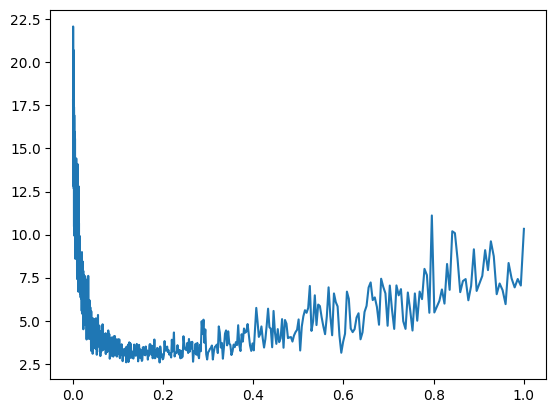

In [188]:
import matplotlib.pyplot as plt

plt.plot(lri, lossi)

Here we can see, the lowest loss is around between 0.0 and 0.2, so the best lr is approx 0.1, which we were using

In [191]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True


In [207]:
# now we can crank up the epochs and train nicely, since we know the best LR

LR = 0.1 / 10
EPOCHS = 10000
BATCH_SIZE = 32

for epoch in range(EPOCHS):

    ix = torch.randint(0, X.shape[0], (BATCH_SIZE,))

    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y[ix]) #same stuff

    # print(loss.item()) #will only look at the whole loss and not the batch loss from now
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #gradient descent
    for p in parameters:
        p.data -= LR * p.grad

In [208]:
# forward propagation to calculate total loss

emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, y) #same stuff
loss.item()

2.3178627490997314

Now if we arent making a dent, we can do lr decay, that means we should divide the LR with 10, so that LR is a bit less now 

In [202]:
0.1/10

0.01

So, in industry, the things arent 100% same, but you do the same thing, forwardpass->backwardPass->update, and in later stages of training, you introduce learning rate decay

In [6]:
import random
import torch
import torch.nn.functional as F

def build_dataset(words):
    BLOCK_SIZE = 3 # how many chars do you want to use to predict the next char?
    X, y = [], []

    for w in words:
        context = [0] * BLOCK_SIZE
        for ch in w+'.':
            X.append(context)
            ix = stoi[ch]
            y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    y = torch.tensor(y)
    print(X.shape, y.shape)
    return X, y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, ytr = build_dataset(words[:n1])
Xde, yde = build_dataset(words[n1:n2])
Xte, yte = build_dataset(words[n2:])


torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22928, 3]) torch.Size([22928])


In [221]:
Xtr.shape

torch.Size([182580, 3])

In [225]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True


In [254]:
# now we can crank up the epochs and train nicely, since we know the best LR

LR = 0.1 / 10
EPOCHS = 10000
BATCH_SIZE = 32

for epoch in range(EPOCHS):

    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,))

    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, ytr[ix]) #same stuff

    # print(loss.item()) #will only look at the whole loss and not the batch loss from now
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #gradient descent
    for p in parameters:
        p.data -= LR * p.grad

In [255]:
# forward propagation to calculate total loss

emb = C[Xde]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, yde) #same stuff
loss.item()

2.8225648403167725

Now we are stuck at 2.8, and we arent overfitting...we are underfitting...So one of the easiest ways to overcome that is by making the architecture of NN bigger

In [8]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True


print(f"total parameters to train {sum(p.nelement() for p in parameters)}")


total parameters to train 10281


In [19]:
# now we can crank up the epochs and train nicely, since we know the best LR

LR = 0.01
EPOCHS = 30000
BATCH_SIZE = 64
stepi = []
lossi = []

for epoch in range(EPOCHS):

    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,))

    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, ytr[ix]) #same stuff

    # print(loss.item()) #will only look at the whole loss and not the batch loss from now
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #gradient descent
    for p in parameters:
        p.data -= LR * p.grad

    stepi.append(epoch)
    lossi.append(loss.item())

In [21]:
# forward propagation to calculate total loss

emb = C[Xde]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, yde) #same stuff
print(f"{loss.item():.4f}")

2.2521


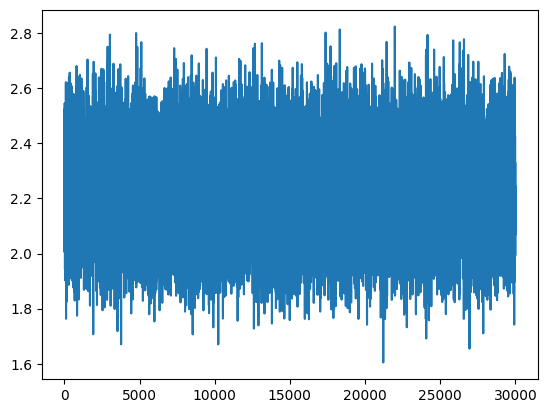

In [23]:
import matplotlib.pyplot as plt
plt.plot(stepi, lossi)

In [30]:
C[:]

tensor([[ 0.4987, -0.2338],
        [ 0.0274, -0.3615],
        [ 0.3575,  0.8272],
        [ 0.3459,  0.3950],
        [ 0.1098,  0.4550],
        [-0.2910, -0.3309],
        [ 0.1697,  0.8262],
        [ 0.3912,  1.3887],
        [-0.0857,  0.2374],
        [-0.6576, -0.2955],
        [-0.1865,  0.4602],
        [ 0.1264,  0.3980],
        [-0.4555,  0.7690],
        [-0.0224,  0.6486],
        [-0.6197,  0.2279],
        [-0.1525, -0.5915],
        [ 0.3707,  0.5268],
        [-1.3847,  0.3612],
        [-0.3788,  0.3954],
        [ 0.1923,  0.2172],
        [ 0.1935,  0.3049],
        [ 0.6136,  2.0716],
        [ 0.0530,  0.8836],
        [-0.2824,  0.2235],
        [-0.0234,  0.1987],
        [-1.0582, -0.2000],
        [ 0.0080,  0.3806]], grad_fn=<SliceBackward0>)

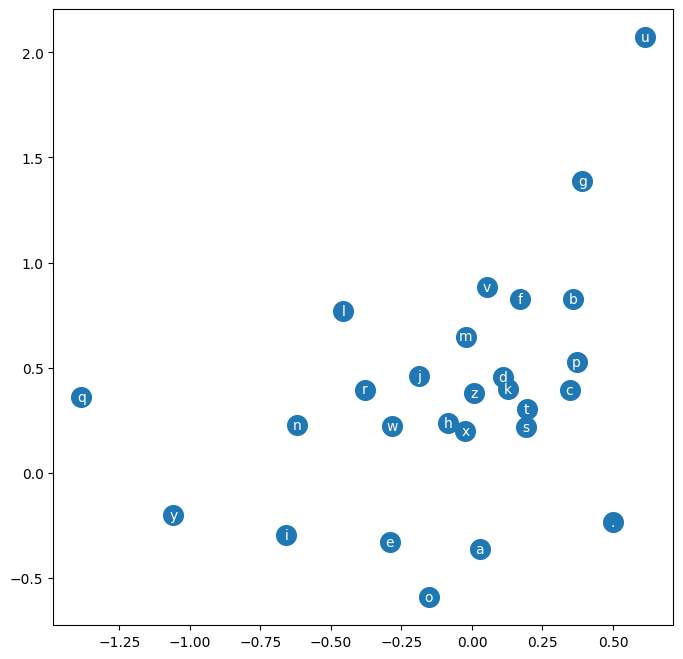

In [31]:
plt.figure(figsize=(8,8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i, 1].item(), itos[i], ha="center", va='center', color='white')
plt.grid(which='minor')

Right now, we are turning every char into a 2d vector aka a point on this map, we can make it into a 3d vector as well....in bengio's paper, he has used 30d for embeddings

In [33]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True


print(f"total parameters to train {sum(p.nelement() for p in parameters)}")


total parameters to train 11897


In [59]:
LR = 0.01
EPOCHS = 200000
BATCH_SIZE = 64
stepi = []
lossi = []

In [60]:

for epoch in range(EPOCHS):

    ix = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,))

    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, ytr[ix]) #same stuff

    # print(loss.item()) #will only look at the whole loss and not the batch loss from now
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #gradient descent
    for p in parameters:
        p.data -= LR * p.grad

    stepi.append(epoch)
    lossi.append(loss.item())

    # forward propagation to calculate total loss

emb = C[Xde]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, yde) #same stuff
print(f"{loss.log10().item():.4f}")


0.3338


In [57]:
# forward propagation to calculate total loss

emb = C[Xde]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, yde) #same stuff
print(f"{loss.item():.4f}")

2.1620


In [58]:
# forward propagation to calculate total loss

emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, ytr) #same stuff
print(f"{loss.item():.4f}")

2.1063


In [64]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * 3

    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        prob = F.softmax(logits, dim=1)
        ix = torch.multinomial(prob, num_samples=1, generator=g).item()
        context = context[1:]+[ix]
        out.append(ix)

        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

carmahela.
jharlin.
mili.
taty.
skaelane.
mahnevalee.
art.
kaeli.
nekonia.
chaiir.
kaleigh.
ham.
poin.
quintin.
lilea.
jamilion.
elogiearisika.
jenni.
sather.
emi.
